In [12]:
#task1 data preperation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from google.colab import files
#uploaded = files.upload()
df = pd.read_csv("q2_customers.csv")

# Scale features (Required for KMeans)
print(df.columns)
features = ["age", "annual_spend", "visits_per_month", "basket_size","days_since_last_visit","num_categories_purchased"]
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Index(['age', 'annual_spend', 'visits_per_month', 'basket_size',
       'days_since_last_visit', 'num_categories_purchased'],
      dtype='object')


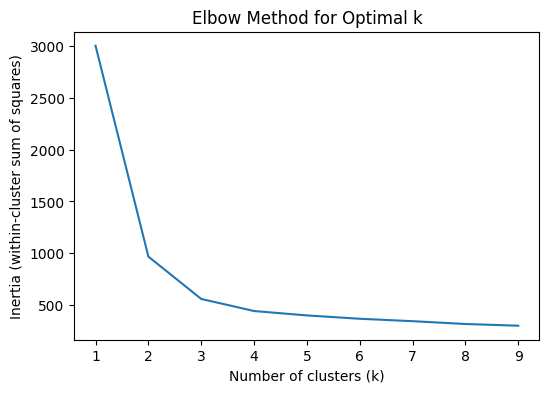

In [13]:
#task 2 : elbow method to choose K
inertias = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.show()

In [14]:
k = 3

In [15]:
#The optimal number of clusters is 3, as the elbow point appears at K = 3 where the WCSS reduction starts to level off.
#This indicates that adding more clusters beyond 3 provides diminishing returns in improving cluster compactness.

In [16]:
#task3 Kmeans clustering
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters
print(df[["Cluster"] + features])

     Cluster  age  annual_spend  visits_per_month  basket_size  \
0          2   30         43075                 9         2080   
1          0   19         14496                11          454   
2          2   43         57632                 6         2144   
3          0   30         15629                10          801   
4          0   19         14901                16          396   
..       ...  ...           ...               ...          ...   
495        0   20         22094                13          729   
496        1   53         63845                 1         7371   
497        2   44         53558                 9          906   
498        2   36         41202                 9         2046   
499        0   20          8118                15          865   

     days_since_last_visit  num_categories_purchased  
0                       45                         6  
1                        8                         3  
2                       16                

In [17]:
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_original, columns=features)
centers_df["Cluster"] = range(k)
print(centers_df)

         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  Cluster  
0               9.076471                  2.111765        0  
1             105.357576                  7.515152        1  
2              35.187879                  4.424242        2  


In [18]:
#cluster 0: young, less spendors, frequent visit, low basket size
#cluster 1: old, high spendors, low visits, big basket size
#cluster 2: medium age, medium visits, medium basket size

In [19]:
#Dimentionality reduction with PCA
# visualize clusters with PCA (4 features into 2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

# explain the principal components
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Components (loadings):")
loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=["PC1", "PC2"]
)
print(loadings)

Explained variance ratio: [0.83560354 0.05568764]
Components (loadings):
          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


In [20]:
#from the explained varience ratio, it can be seen that the PCA1 is covering most of the information (83%) compared to PCA2 (5%).
#Looking at the loadings, PC1 has strong positive contributions from features like annual spend, basket size, number of categories purchased,
#age, and days since last visit, while visits per month contributes negatively suggesting 2 imprtant groups of customers, 1st are old people
#high spendors with big basket size but visit less frequently, 2nd are the young customers who visit frequently but spend less with low basket size
#

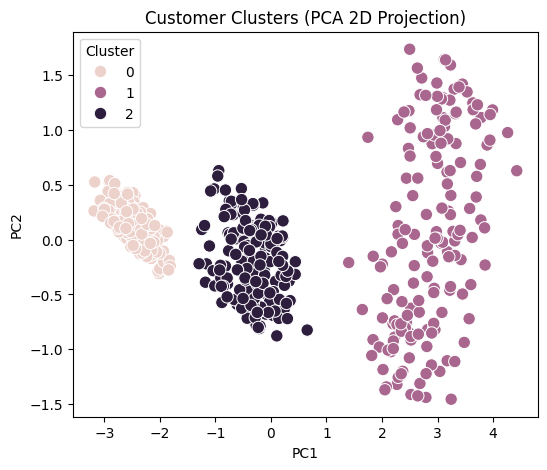

In [21]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=80
)
plt.title("Customer Clusters (PCA 2D Projection)")
plt.legend(title="Cluster")
plt.show()